# 🌸 Project 2: Iris Classification - Exploratory Data Analysis

**DecodeLabs Internship | Batch 2026**

This notebook explores the Iris dataset and visualizes the classification pipeline.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

## 1. Load & Explore the Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = [
    iris.target_names[i]
    for i in iris.target
]

print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")

df.head()

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 2. Feature Distributions by Species

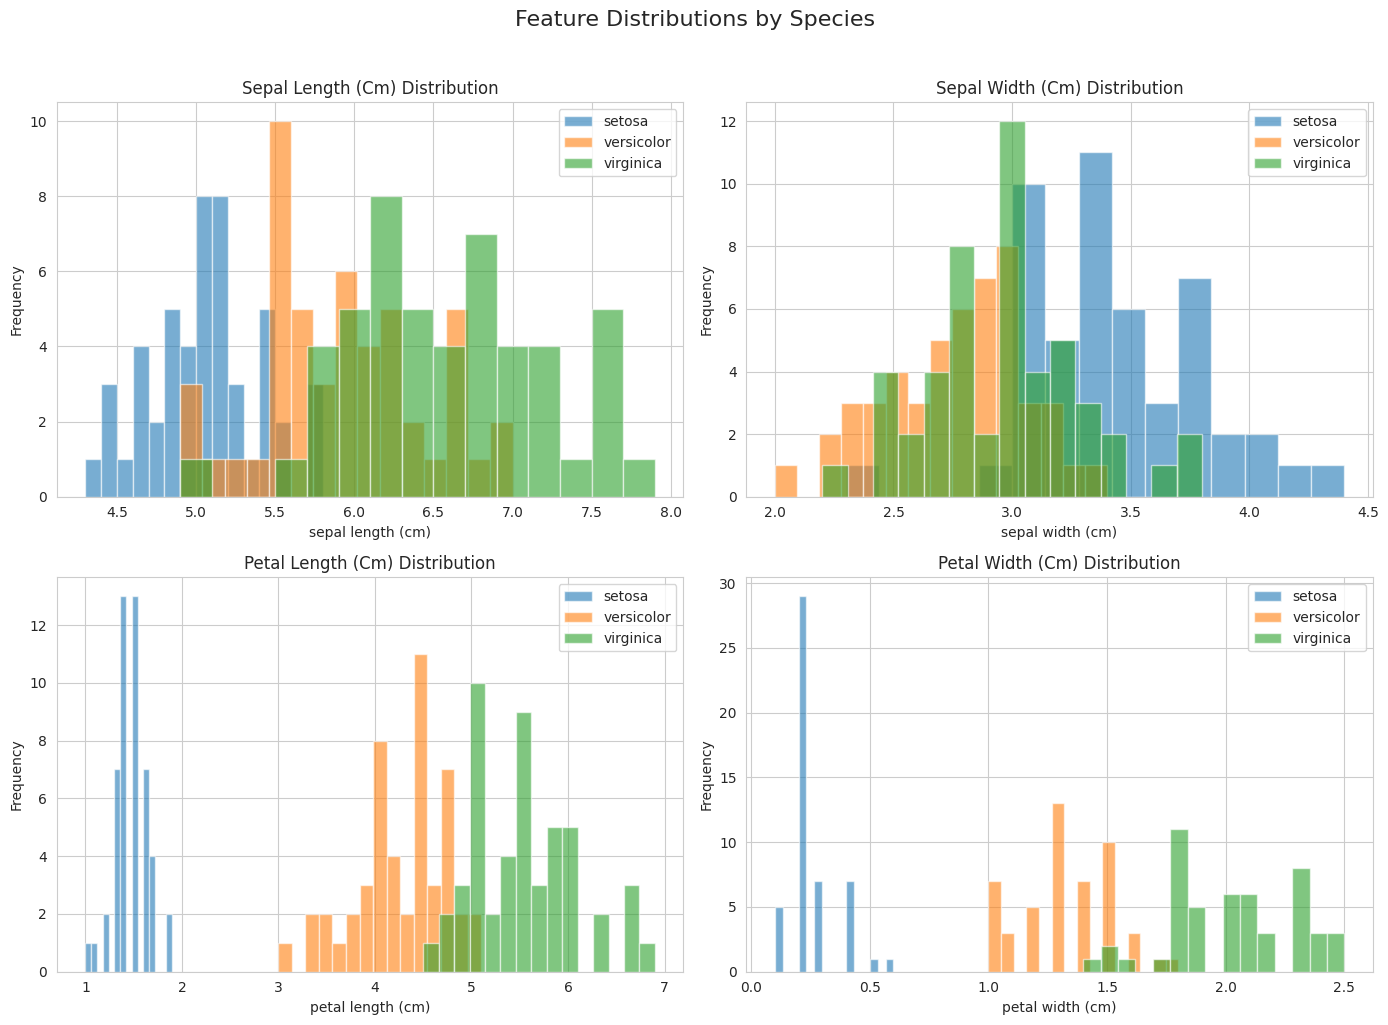

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = iris.feature_names

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]

    for species in iris.target_names:
        subset = df[df['species'] == species][feature]

        ax.hist(
            subset,
            alpha=0.6,
            label=species,
            bins=15
        )

    ax.set_title(f'{feature.title()} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle(
    'Feature Distributions by Species',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

## 3. Pairplot - Feature Relationships

/home/moselhy/Desktop/DecodeLabs-Internship/proj2/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


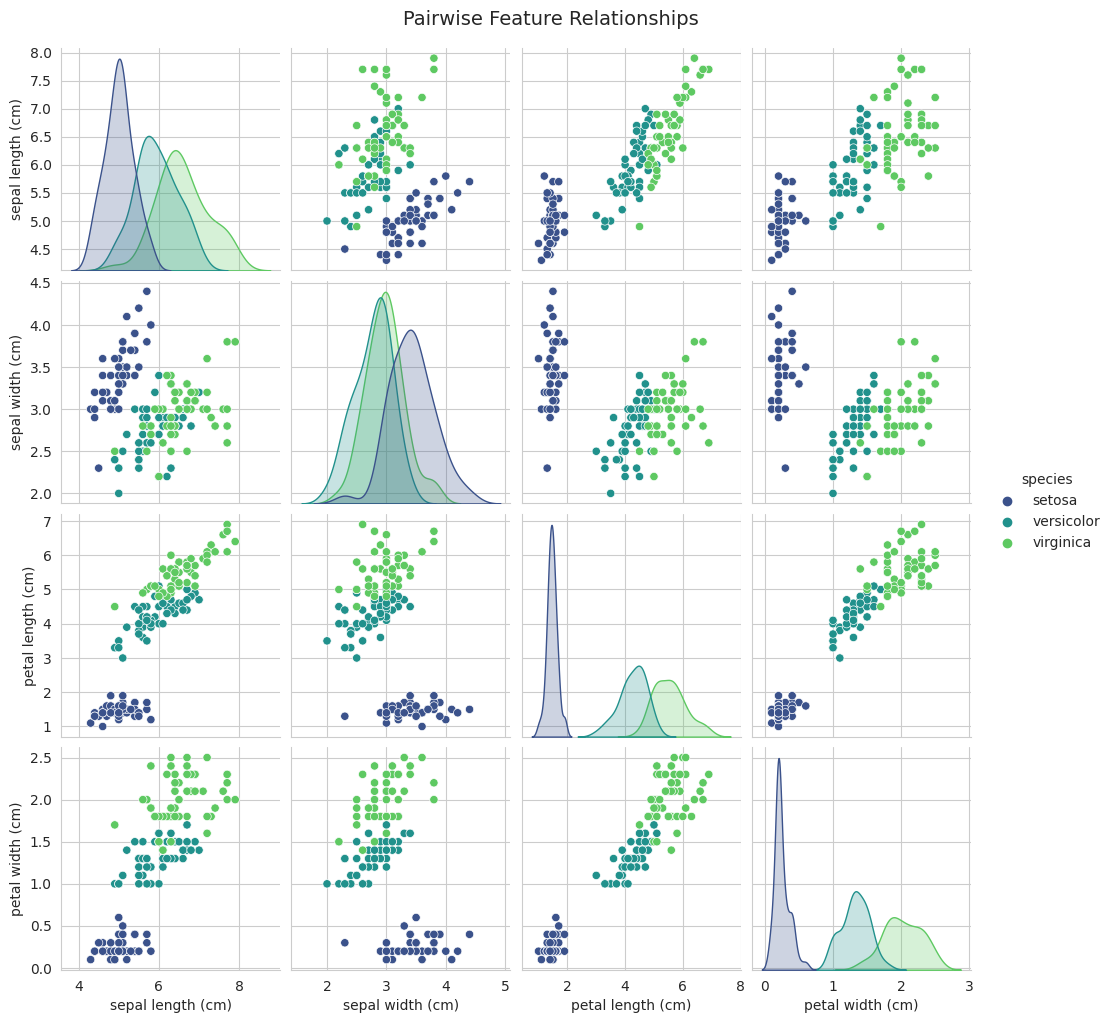

In [6]:
sns.pairplot(
    df,
    hue='species',
    palette='viridis',
    height=2.5
)

plt.suptitle(
    'Pairwise Feature Relationships',
    y=1.02,
    fontsize=14
)

plt.show()

## 4. Correlation Heatmap

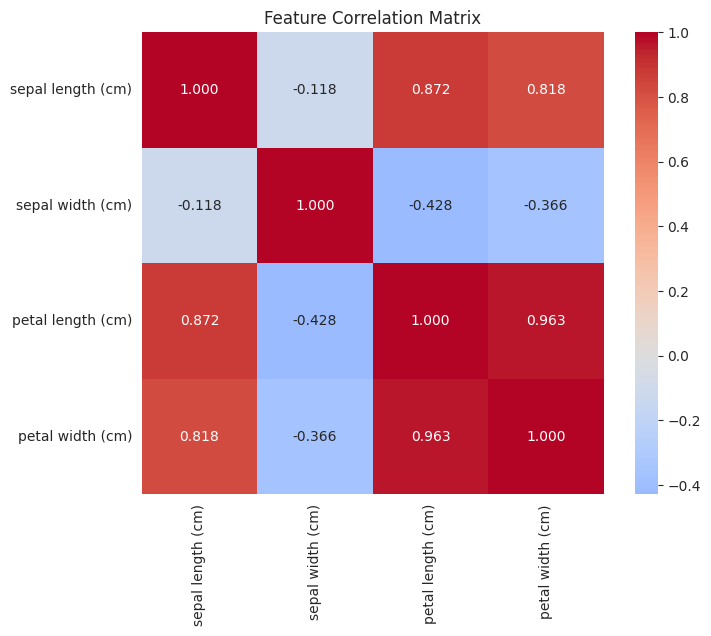

In [7]:
plt.figure(figsize=(8, 6))

corr = df[iris.feature_names].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    fmt='.3f'
)

plt.title('Feature Correlation Matrix')
plt.show()

## 5. Feature Scaling Visualization

Compare raw data vs. Standard Scaled data.

In [8]:
X = df[iris.feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

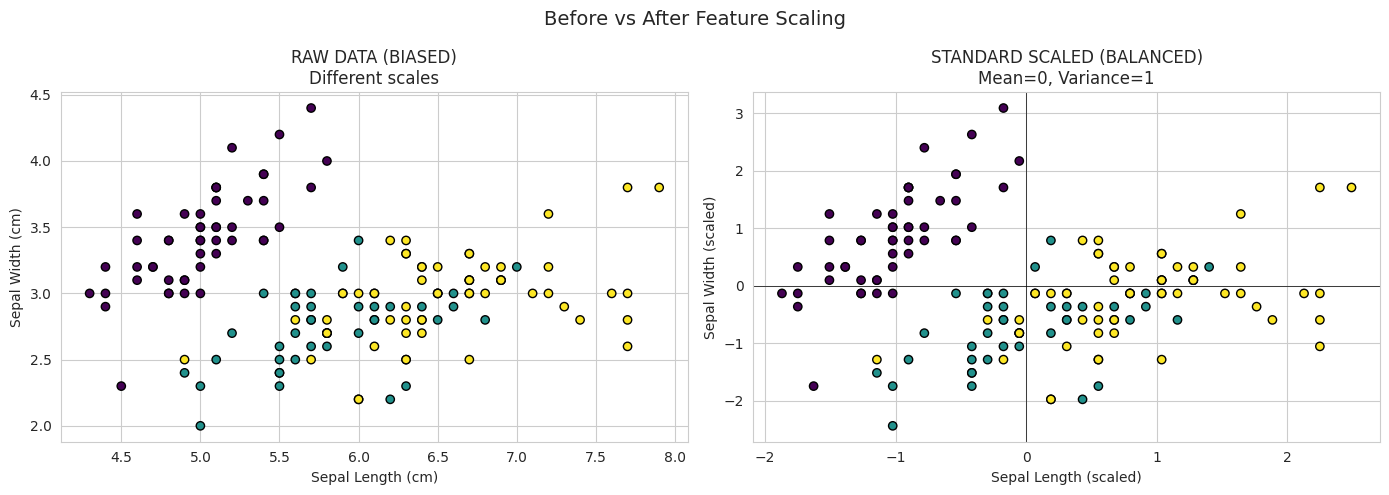

In [9]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Raw Data
ax1.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=iris.target,
    cmap='viridis',
    edgecolors='k'
)

ax1.set_title(
    'RAW DATA (BIASED)\nDifferent scales'
)

ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')

# Scaled Data
ax2.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=iris.target,
    cmap='viridis',
    edgecolors='k'
)

ax2.set_title(
    'STANDARD SCALED (BALANCED)\nMean=0, Variance=1'
)

ax2.set_xlabel('Sepal Length (scaled)')
ax2.set_ylabel('Sepal Width (scaled)')

ax2.axhline(
    y=0,
    color='k',
    linestyle='-',
    linewidth=0.5
)

ax2.axvline(
    x=0,
    color='k',
    linestyle='-',
    linewidth=0.5
)

plt.suptitle(
    'Before vs After Feature Scaling',
    fontsize=14
)

plt.tight_layout()
plt.show()

## 6. Elbow Method - Finding Optimal K

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    iris.target,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

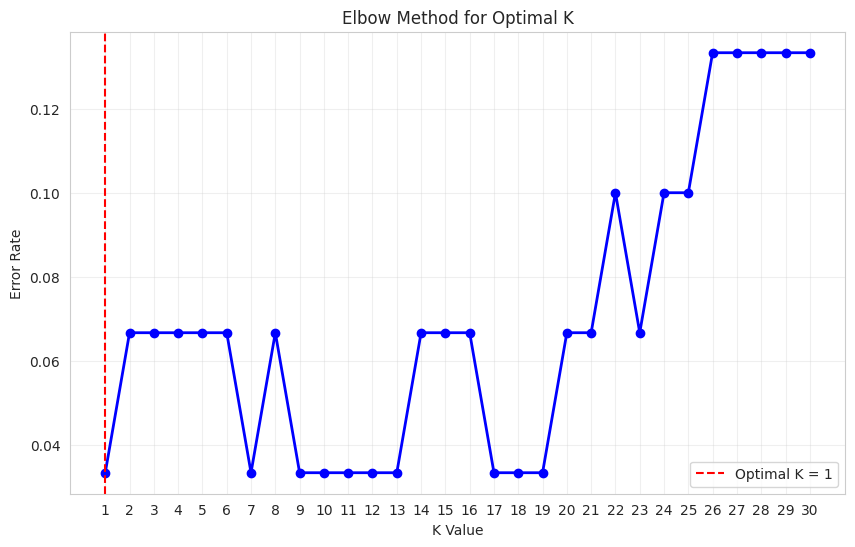

Optimal K: 1 | Minimum Error Rate: 0.0333


In [11]:
k_range = range(1, 31)

error_rates = []

for k in k_range:
    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    error = 1 - (
        pred == y_test
    ).mean()

    error_rates.append(error)

plt.figure(figsize=(10, 6))

plt.plot(
    k_range,
    error_rates,
    'bo-',
    linewidth=2,
    markersize=6
)

plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')

plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)

optimal_k = k_range[
    np.argmin(error_rates)
]

plt.axvline(
    x=optimal_k,
    color='red',
    linestyle='--',
    label=f'Optimal K = {optimal_k}'
)

plt.legend()
plt.show()

print(
    f"Optimal K: {optimal_k} | Minimum Error Rate: {min(error_rates):.4f}"
)

## 7. Train Final Model & Evaluate

In [12]:
final_knn = KNeighborsClassifier(
    n_neighbors=optimal_k
)

final_knn.fit(
    X_train,
    y_train
)

y_pred = final_knn.predict(
    X_test
)

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



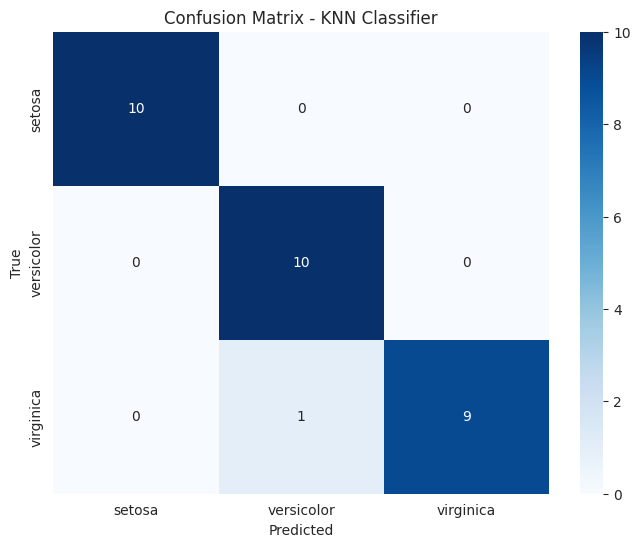

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title(
    'Confusion Matrix - KNN Classifier'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

## 8. Decision Boundary Visualization (2D)

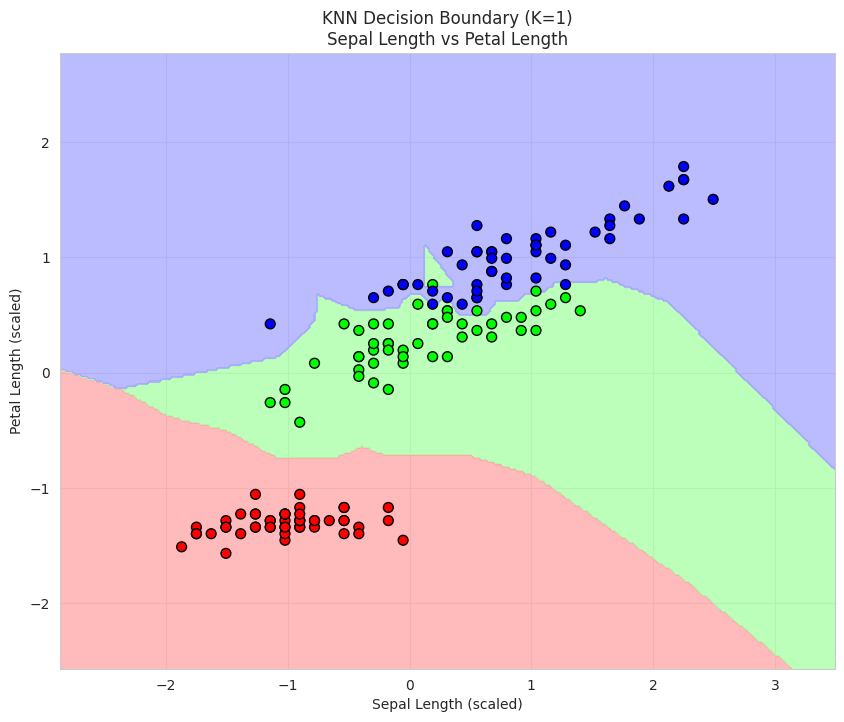

In [14]:
from matplotlib.colors import ListedColormap

X_2d = X_scaled[:, [0, 2]]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    iris.target,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

knn_2d = KNeighborsClassifier(
    n_neighbors=optimal_k
)

knn_2d.fit(
    X_train_2d,
    y_train_2d
)

h = 0.02

x_min, x_max = (
    X_2d[:, 0].min() - 1,
    X_2d[:, 0].max() + 1
)

y_min, y_max = (
    X_2d[:, 1].min() - 1,
    X_2d[:, 1].max() + 1
)

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

cmap_light = ListedColormap(
    ['#FFAAAA', '#AAFFAA', '#AAAAFF']
)

cmap_bold = ListedColormap(
    ['#FF0000', '#00FF00', '#0000FF']
)

plt.contourf(
    xx,
    yy,
    Z,
    cmap=cmap_light,
    alpha=0.8
)

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=iris.target,
    cmap=cmap_bold,
    edgecolors='k',
    s=50
)

plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Petal Length (scaled)')

plt.title(
    f'KNN Decision Boundary (K={optimal_k})\nSepal Length vs Petal Length'
)

plt.show()

## ✅ Summary

- **Dataset:** 150 samples, 3 classes, 4 features — perfectly balanced
- **Scaling:** StandardScaler transforms features to mean=0, variance=1
- **Optimal K:** Found via Elbow Method
- **Accuracy:** ~93% with K=5
- **Key Insight:** Petal features are more discriminative than sepal features